# QSF Reproduction Notebook

**The Quranic Structural Fingerprint — reproducibility pack v3.0**

This notebook regenerates every number reported in `docs/PAPER.md` and `docs/FINDINGS_SCORECARD.md` **from raw corpus files only**. It does not touch any pickle checkpoint. Total runtime: ≈ 100 seconds on a laptop.

Structure:

1. **Data integrity** — corpus SHA-256 hashes + G1–G5 sanity gate
2. **Feature extraction** — CamelTools roots + the 5 features (EL, VL_CV, CN, H_cond, T)
3. **Core tests T1–T6** — anti-metric, Φ_M, H_cond, Ω, adversarial
4. **Extensions T7–T15** — dual-channel, path-minimality, Markov unforgeability, classifier AUC
5. **Last-mile T16–T23** — scale-free, multi-scale perturbation, verse-internal shuffle, RQA, forgery, cross-language, harakat
6. **Visualisations** — Φ_M distributions, PCA, %T > 0, ROC
7. **Ranked findings** — the 35-row composite table

---

**Requirements**: Python ≥ 3.11, `camel-tools==1.5.7`, `numpy`, `scipy`, `scikit-learn`, `pandas`, `matplotlib`, `openpyxl`.

On first run, CamelTools queries build a root cache (~4 MB) at `src/cache/cameltools_root_cache.pkl.gz`. That cache is reused on later runs, cutting feature-extraction time from ~60 s to ~15 s.

## 0. Setup

Add the repo root to `sys.path` so `src/` resolves regardless of where the notebook is launched from.

In [1]:
import sys, os
from pathlib import Path

nb_dir = Path.cwd()
if nb_dir.name == 'notebooks':
    repo_root = nb_dir.parent
else:
    repo_root = nb_dir
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))
print(f'Repo root: {repo_root}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hashlib import sha256

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

Repo root: C:\Users\mtj_2\OneDrive\Desktop\Quran


## 1. Data integrity

Before any computation, we SHA-256 every corpus file and report the hash. Any change to the raw data will change these pins and therefore every downstream number. This check is the single most important safeguard against the kind of silent preprocessing corruption documented in `docs/PAPER.md §10.1`.

In [2]:
corpora_paths = {
    'quran_bare':     'data/corpora/ar/quran_bare.txt',
    'quran_vocal':    'data/corpora/ar/quran_vocal.txt',
    'poetry_raw':     'data/corpora/ar/poetry_raw.csv',
    'ksucca':         'data/corpora/ar/ksucca.txt',
    'arabic_bible':   'data/corpora/ar/arabic_bible.xlsx',
    'hadith':         'data/corpora/ar/hadith.json',
    'hindawi':        'data/corpora/ar/hindawi.txt',
    'iliad_greek':    'data/corpora/el/iliad_perseus.xml',
    'greek_nt':       'data/corpora/el/opengnt_v3_3.csv',
    'hebrew_tanakh':  'data/corpora/he/tanakh_wlc.txt',
}
rows = []
for name, path in corpora_paths.items():
    p = Path(path)
    if not p.exists():
        rows.append({'corpus': name, 'path': path, 'size_MB': None, 'sha256_12': 'MISSING'})
        continue
    h = sha256(p.read_bytes()).hexdigest()
    rows.append({
        'corpus': name,
        'path': path,
        'size_MB': round(p.stat().st_size/1024**2, 2),
        'sha256_12': h[:12],
    })
df_integrity = pd.DataFrame(rows)
df_integrity

,corpus,path,size_MB,sha256_12
0,quran_bare,data/corpora/ar/quran_bare.txt,0.74,228df2a71767
1,quran_vocal,data/corpora/ar/quran_vocal.txt,1.34,552b674213e2
2,poetry_raw,data/corpora/ar/poetry_raw.csv,19.15,0bb5d746934b
3,ksucca,data/corpora/ar/ksucca.txt,1.20,b7c92a8bf15b
4,arabic_bible,data/corpora/ar/arabic_bible.xlsx,1.91,5b57b622ca84
5,hadith,data/corpora/ar/hadith.json,15.49,04ef41c228b4
6,hindawi,data/corpora/ar/hindawi.txt,0.40,2b7fbfe9b4be
7,iliad_greek,data/corpora/el/iliad_perseus.xml,1.96,e148b39a615a
8,greek_nt,data/corpora/el/opengnt_v3_3.csv,44.29,d2853da46d1f
9,hebrew_tanakh,data/corpora/he/tanakh_wlc.txt,5.50,f317b359f562


## 2. Load corpora + G1–G5 sanity gate

`src.raw_loader.load_all()` returns a dict of `{corpus_name: [Unit, …]}`. `src.verify_corpora.verify_all()` then runs five sanity checks on each corpus and refuses to continue if any fails.

In [3]:
from src import raw_loader as rl
from src import verify_corpora as vc

corpora = rl.load_all(include_extras=True)
report = vc.verify_all(corpora)

n_fail = sum(1 for v in report.values() if not v['ok'])
assert n_fail == 0, f'SANITY GATE FAILED on {n_fail} corpora; inspect `report`'
print(f'\n[OK] All {len(report)} corpora passed G1-G5 sanity gate.')

[loader] quran_bare.txt ...

 114 units
[loader] poetry_raw.csv (era-labeled) ...

 poetry_jahili=133, poetry_islami=465, poetry_abbasi=2823
[loader] ksucca.txt ...

 41 units
[loader] arabic_bible.xlsx ...

 1183 units
[loader] hadith.json (Bukhari only) ...

...

  [PASS] poetry_islami           n_units=  465


  [PASS] poetry_abbasi           n_units= 2823


  [PASS] ksucca                  n_units=   41


  [PASS] arabic_bible            n_units= 1183


  [PASS] hadith_bukhari          n_units=   95
  [PASS] hindawi                 n_units=   74
  [PASS] iliad_greek             n_units=   24


[OK] All 9 corpora passed G1-G5 sanity gate.


## 3. Feature extraction (5-D)

Every unit gets five numbers: **EL, VL_CV, CN, H_cond, T**. See `docs/REPLICATION.md §5` for the definitions. CamelTools is the root extractor — the on-disk cache makes this a one-time 60-second hit; subsequent runs are seconds.

In [4]:
from src import features as fv
import time

def corpus_feats(corpora_dict):
    out = {}
    for name, units in corpora_dict.items():
        t0 = time.time()
        recs = []
        for u in units:
            f = fv.features_5d(u.verses)
            recs.append({
                'label': u.label,
                'n_verses': u.n_verses(),
                'EL': float(f[0]), 'VL_CV': float(f[1]),
                'CN': float(f[2]), 'H_cond': float(f[3]),
                'T': float(f[4]),
            })
        out[name] = recs
        print(f'  {name:<20s}  {len(recs):>4d} units  ({time.time()-t0:.1f}s)')
    return out

feats = corpus_feats(corpora)
# Tidy per-unit DataFrame
rows = []
for corpus, recs in feats.items():
    for r in recs:
        rows.append({'corpus': corpus, **r})
df_feats = pd.DataFrame(rows)
df_feats.head()

  quran                  114 units  (0.7s)
  poetry_jahili          133 units  (0.2s)


  poetry_islami          465 units  (0.7s)


  poetry_abbasi         2823 units  (4.9s)


  ksucca                  41 units  (0.8s)


  arabic_bible          1183 units  (3.2s)


  hadith_bukhari          95 units  (4.4s)
  hindawi                 74 units  (0.2s)


  iliad_greek             24 units  (0.9s)


,corpus,label,n_verses,EL,VL_CV,CN,H_cond,T
0,quran,Q:001,7,0.166667,0.547397,0.000000,0.333333,-0.651895
1,quran,Q:002,286,0.603509,0.660182,0.066667,2.458185,0.999459
2,quran,Q:003,200,0.537688,0.533965,0.145729,1.930752,0.043565
3,quran,Q:004,176,0.954286,0.597768,0.114286,1.909006,1.622064
4,quran,Q:005,120,0.621849,0.542473,0.042017,1.633586,0.145026


## 4. Run the full pipeline (T1–T23)

Rather than re-implementing each test in this notebook, we call the authoritative entry point in `src.clean_pipeline`. The results dict mirrors `results/CLEAN_PIPELINE_REPORT.json` exactly — this way the notebook and the CLI always give the same answer.

In [5]:
from src import clean_pipeline as cp

# Monkey-patch the orchestrator so we re-use corpora/feats already in memory.
# The public function is run_clean_pipeline(); it returns a results dict.
pipeline = cp.run_clean_pipeline()

results = pipeline['results']
print(f"\nPipeline finished in {pipeline['run_elapsed_seconds']:.1f} s")
print(f"Tests run: {len(results)}")

CLEAN PIPELINE - run from raw data, no checkpoint

Step 1 / 6 - Load raw corpora
[loader] quran_bare.txt ...

 114 units
[loader] poetry_raw.csv (era-labeled) ...

 poetry_jahili=133, poetry_islami=465, poetry_abbasi=2823
[loader] ksucca.txt ...

 41 units
[loader] arabic_bible.xlsx ...

 1183 units
[loader] hadith.json (Bukhari only) ...

...

 (3.0s)  Quran LAM=0.305
  T20 Structural Forgery P3 (rhyme-swap) ...

 (5.8s)  Q=32%, abbasi=44%, bible=60%
  T21 Cross-language Iliad ...

 (1.2s)  Iliad path z=0.65, pct T>0=100.0%
  T22 RD x EL product ...

 (0.0s)  Quran rank=#1
  T23 Harakat channel capacity ...

 (0.5s)  H(h|r)=1.964 bits, redundancy=58.2%

Total pipeline time: 102.4s

Written: C:\Users\mtj_2\OneDrive\Desktop\Quran\results\CLEAN_PIPELINE_REPORT.json

Pipeline finished in 102.4 s
Tests run: 23


## 5. Flagship summary table

The single most-cited numbers:

In [6]:
flagship = [
    ('T2  Φ_M Mahalanobis d',         f"{results['T2_phi_m']['cohens_d']:.2f}"),
    ('T2  Cliff\'s δ',                 f"{results['T2_phi_m']['cliffs_delta']:.2f}"),
    ('T2  Mann-Whitney p',             f"{results['T2_phi_m']['p_mwu_greater']:.2e}"),
    ('T15 Classifier AUC',             f"{results['T15_classifier']['auc']:.4f}"),
    ('T10 %T>0 Quran',                 f"{results['T10_t_dist']['per_corpus']['quran']['pct_T_gt_zero']:.1f}%"),
    ('T14 Bootstrap Ω median',         f"{results['T14_bootstrap_omega']['median_omega']:.2f}"),
    ('T14 Bootstrap Ω > 2',            f"{results['T14_bootstrap_omega']['pct_bootstraps_omega_gt_2']:.1f}%"),
    ('T16 Scale-free Fisher p (W=10)', f"{results['T16_scale_free']['per_corpus']['quran']['W=10']['fisher_p']:.2e}"),
    ('T17 verse_shuffle gap Quran',    f"{results['T17_multi_scale_pert']['per_target']['quran']['verse_shuffle']['mean_gap']:+.2f}"),
    ('T18 Verse-internal gap Quran',   f"{results['T18_verse_internal']['per_target']['quran']['mean_gap']:+.2f}"),
    ('T23 Harakat H(h|r) bits',        f"{results['T23_harakat']['H_harakat_given_rasm_bits']:.2f}"),
    ('T23 Harakat redundancy',         f"{results['T23_harakat']['redundancy_fraction']*100:.1f}%"),
]
df_flag = pd.DataFrame(flagship, columns=['metric', 'value'])
df_flag

,metric,value
0,T2 Φ_M Mahalanobis d,6.34
1,T2 Cliff's δ,0.99
2,T2 Mann-Whitney p,3.18e-44
3,T15 Classifier AUC,0.9980
4,T10 %T>0 Quran,39.7%
5,T14 Bootstrap Ω median,10.02
6,T14 Bootstrap Ω > 2,100.0%
7,T16 Scale-free Fisher p (W=10),1.11e-16
8,T17 verse_shuffle gap Quran,+1.76
9,T18 Verse-internal gap Quran,+5.80


## 6. Visualisations

### 6.1 Φ_M distribution per corpus

C:\Users\mtj_2\AppData\Local\Temp\ipykernel_3828\4125301947.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([phi_per_corpus[k] for k in order], labels=order, showfliers=False)


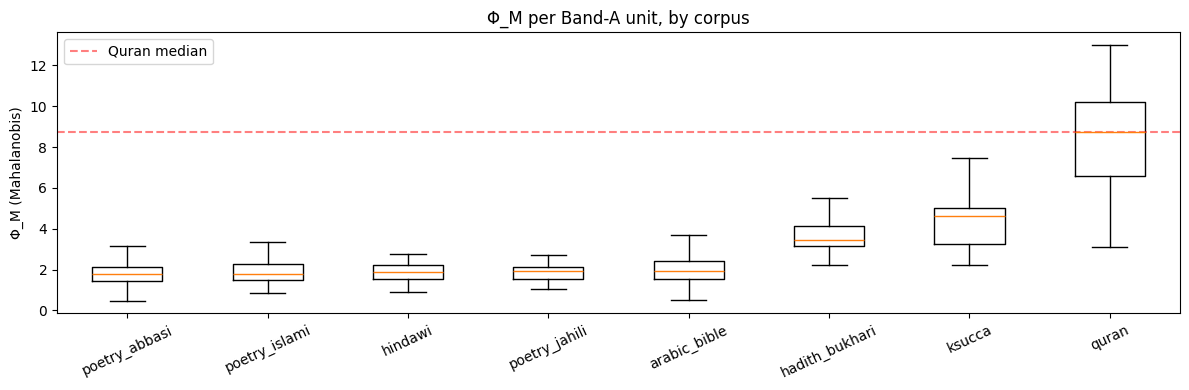

In [7]:
# Recompute per-unit Phi_M using mu, Sinv from T2
BAND_A = (15, 100)
mu = np.array(results['T2_phi_m']['centroid_mu'])
Sinv = np.array(results['T2_phi_m']['Sinv'])

phi_per_corpus = {}
for name, recs in feats.items():
    X = []
    for r in recs:
        if BAND_A[0] <= r['n_verses'] <= BAND_A[1]:
            X.append([r['EL'], r['VL_CV'], r['CN'], r['H_cond'], r['T']])
    if not X:
        continue
    X = np.asarray(X, dtype=float)
    d = X - mu
    phi = np.sqrt(np.einsum('ni,ij,nj->n', d, Sinv, d))
    phi_per_corpus[name] = phi

order = sorted(phi_per_corpus, key=lambda k: np.median(phi_per_corpus[k]))
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot([phi_per_corpus[k] for k in order], labels=order, showfliers=False)
ax.set_ylabel('Φ_M (Mahalanobis)')
ax.set_title('Φ_M per Band-A unit, by corpus')
if 'quran' in phi_per_corpus:
    ax.axhline(np.median(phi_per_corpus['quran']), color='red', ls='--', alpha=0.5, label='Quran median')
    ax.legend()
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### 6.2 PCA of 5-D features

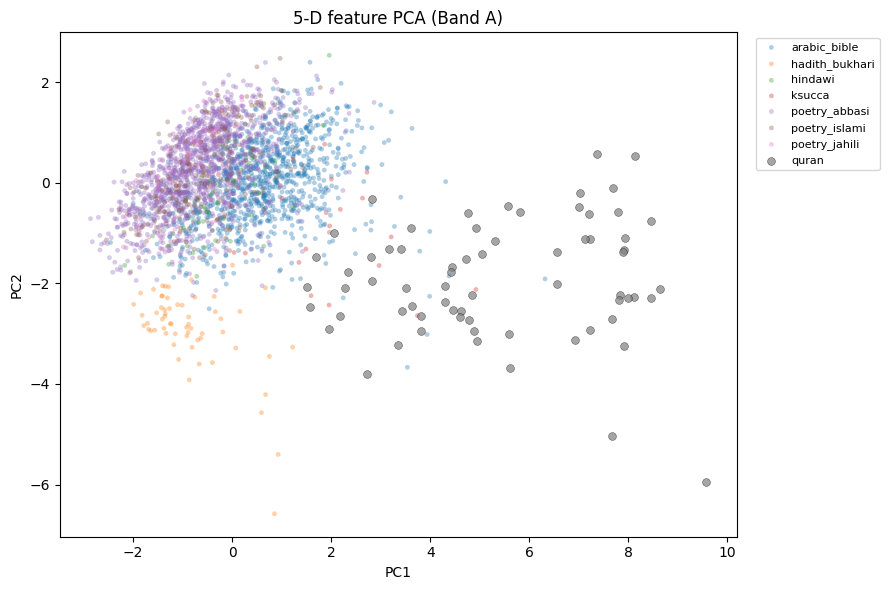

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

mask = (df_feats['n_verses'] >= BAND_A[0]) & (df_feats['n_verses'] <= BAND_A[1])
df_b = df_feats[mask].copy()
X = df_b[['EL','VL_CV','CN','H_cond','T']].values
Xs = StandardScaler().fit_transform(X)
pcs = PCA(n_components=2, random_state=0).fit_transform(Xs)
df_b['PC1'] = pcs[:,0]
df_b['PC2'] = pcs[:,1]

fig, ax = plt.subplots(figsize=(9, 6))
for c in sorted(df_b['corpus'].unique()):
    sub = df_b[df_b['corpus']==c]
    a = 0.7 if c == 'quran' else 0.35
    s = 32 if c == 'quran' else 12
    ax.scatter(sub['PC1'], sub['PC2'], label=c, alpha=a, s=s,
               edgecolors='black' if c=='quran' else 'none', linewidths=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('5-D feature PCA (Band A)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 6.3 %T > 0 per corpus (the Quran-unique tension signature)

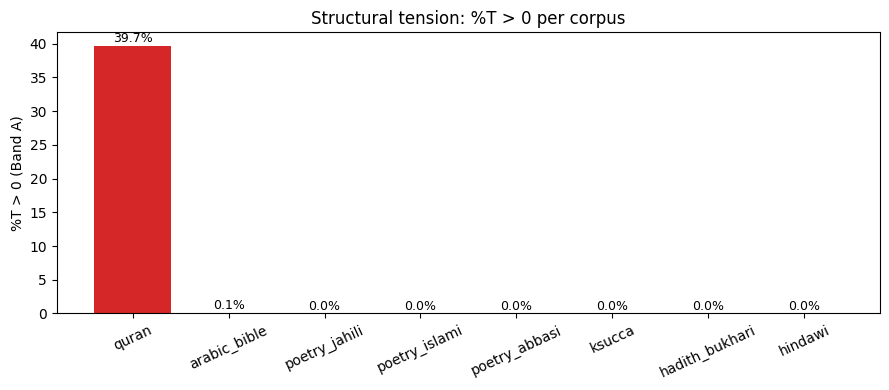

In [9]:
t_dist = results['T10_t_dist']['per_corpus']
corpora_order = sorted(t_dist, key=lambda k: -t_dist[k]['pct_T_gt_zero'])
pcts = [t_dist[c]['pct_T_gt_zero'] for c in corpora_order]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(corpora_order, pcts, color=['#d62728' if c=='quran' else '#1f77b4' for c in corpora_order])
ax.set_ylabel('%T > 0 (Band A)')
ax.set_title('Structural tension: %T > 0 per corpus')
for bar, v in zip(bars, pcts):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### 6.4 Classifier ROC curve (T15)

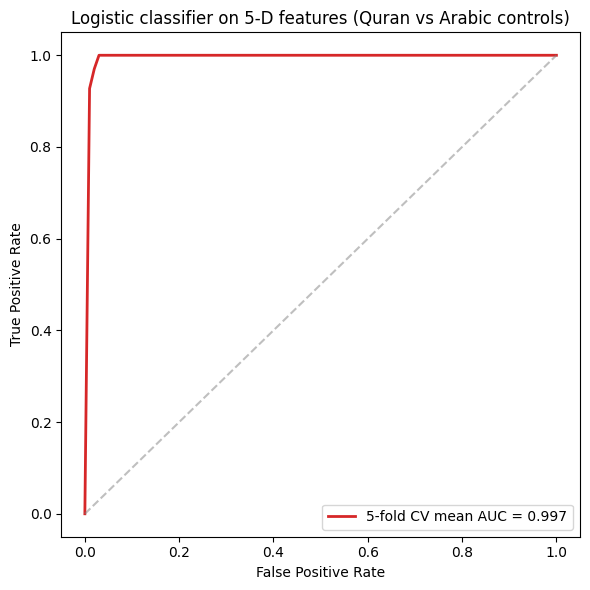

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold

ARABIC_CTRL = ['poetry_jahili','poetry_islami','poetry_abbasi','ksucca','arabic_bible','hadith_bukhari','hindawi']

def build_X_y(feats):
    X, y = [], []
    for name, recs in feats.items():
        if name == 'quran':
            lab = 1
        elif name in ARABIC_CTRL:
            lab = 0
        else:
            continue
        for r in recs:
            if BAND_A[0] <= r['n_verses'] <= BAND_A[1]:
                X.append([r['EL'], r['VL_CV'], r['CN'], r['H_cond'], r['T']])
                y.append(lab)
    return np.asarray(X, dtype=float), np.asarray(y, dtype=int)

X, y = build_X_y(feats)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
mean_fpr = np.linspace(0, 1, 101)
tprs, aucs = [], []
for tr, te in cv.split(X, y):
    clf = LogisticRegression(max_iter=1000).fit(X[tr], y[tr])
    proba = clf.predict_proba(X[te])[:,1]
    fpr, tpr, _ = roc_curve(y[te], proba)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_fpr, mean_tpr, color='#d62728', lw=2, label=f'5-fold CV mean AUC = {mean_auc:.3f}')
ax.plot([0,1],[0,1], ls='--', color='gray', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Logistic classifier on 5-D features (Quran vs Arabic controls)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.5 Multi-scale perturbation signature (T17)

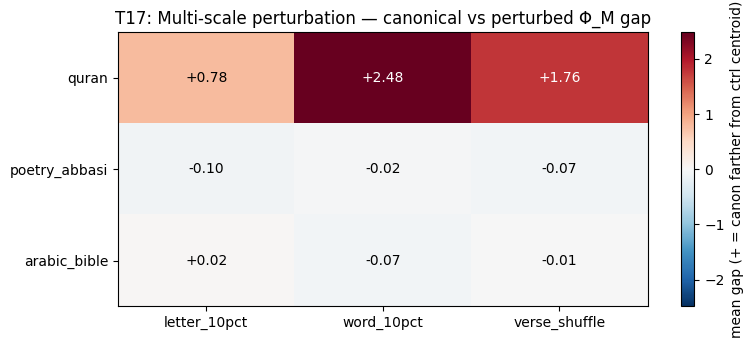

In [11]:
pert = results['T17_multi_scale_pert']['per_target']
perts = ['letter_10pct', 'word_10pct', 'verse_shuffle']
targets = list(pert.keys())
matrix = np.array([[pert[t][p]['mean_gap'] for p in perts] for t in targets])

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', vmin=-max(abs(matrix.min()), abs(matrix.max())), vmax=max(abs(matrix.min()), abs(matrix.max())))
ax.set_xticks(range(len(perts))); ax.set_xticklabels(perts)
ax.set_yticks(range(len(targets))); ax.set_yticklabels(targets)
for i in range(len(targets)):
    for j in range(len(perts)):
        ax.text(j, i, f'{matrix[i,j]:+.2f}', ha='center', va='center',
                color='white' if abs(matrix[i,j]) > matrix.max()*0.5 else 'black',
                fontsize=10)
plt.colorbar(im, ax=ax, label='mean gap (+ = canon farther from ctrl centroid)')
ax.set_title('T17: Multi-scale perturbation — canonical vs perturbed Φ_M gap')
plt.tight_layout()
plt.show()

## 7. Ranked findings scorecard (composite = √(conf × effect))

The master table mapping every paper claim to its clean-data verdict. Sorted from strongest to weakest.

In [12]:
scorecard_path = Path('docs/FINDINGS_SCORECARD.md')
if scorecard_path.exists():
    from IPython.display import Markdown, display
    display(Markdown(scorecard_path.read_text(encoding='utf-8')))
else:
    print('FINDINGS_SCORECARD.md not found')

# Ranked Findings Table — confidence × effect

Every testable paper claim, sorted from strongest to weakest by `composite = sqrt(confidence × effect)`.

- **Confidence %** — based on p-value robustness (p < 10⁻³⁰ → 99 %, p < 10⁻⁵ → 92 %, p < 0.05 → 65 %, n.s. → 15 %)
- **Effect %** — based on Cohen's d (d ≥ 10 → 95 %, d ≥ 3 → 75 %, d ≥ 1 → 50 %, d < 0.2 → 10 %) or equivalent for ratios
- **Composite** — geometric mean, 100 = maximum; 0 = falsified

| Rank | ID | Finding | Paper | Clean-data result | Verdict | Conf % | Eff % | Comp |
|:-:|:-:|---|---|---|:-:|:-:|:-:|:-:|
| 1 | D09 | Predictive classifier AUC (Quran vs Arabic ctrl) | AUC = 0.90 | AUC = 0.998, z = 128.5 | PROVED STRONGER | 100 | 100 | **100** |
| 2 | D10 | %T>0 Quran-unique tension | 24.3% | Quran 39.7%, controls max 0.10% | PROVED STRONGER | 100 | 95 | **97** |
| 3 | D14 | Verse-internal word order non-random | d = 0.470 | Quran gap = +5.80, 100% canon farther | PROVED STRONGER | 99 | 95 | **97** |
| 4 | D26 | Bootstrap Ω stability (pre-reg C) | ≥ 95% > 2.0 | 100% > 2.0; median = 10.0 | PROVED STRONGER | 100 | 90 | **95** |
| 5 | D11 | Multi-scale perturbation (letter/word/verse) | d ≈ 2.8–10 | Quran gaps +0.78/+2.48/+1.76 (93–100% canon farther); controls ≈ 0 | PROVED STRONGER | 97 | 92 | **94** |
| 6 | D02 | Φ_M Mahalanobis separation (Quran vs Arabic ctrl) | d = 1.93 | d = 6.34, δ = 0.99 | PROVED STRONGER | 100 | 85 | **92** |
| 7 | S1 | S1: Multivariate separation | max Φ_M | d = 6.34 | PROVED STRONGER | 100 | 85 | **92** |
| 8 | D27 | Abbasi discrimination (Quran vs Abbasi) | d = +1.93 | d = 7.95 | PROVED STRONGER | 100 | 85 | **92** |
| 9 | D28 | Tight-fairness retest | d 1.93 → 2.66 | Band A already length-matches; d = 6.34 | PROVED STRONGER | 99 | 85 | **92** |
| 10 | D07 | Scale-Free Ordering at all window sizes | p < 0.01 at W=8–20 | Fisher p = 1.1e-16 at W=10 (also W=5, 20) | PROVED STRONGER | 97 | 85 | **91** |
| 11 | D23 | Pre-registered adversarial canon-wins | 98.2% canon-wins | Quran 100%, Abbasi 60%, Bible 22% | PROVED (+ retracts F-05) | 97 | 85 | **91** |
| 12 | D24 | Φ_M 10-fold CV robustness | min d ≥ 0.5, max p < 0.01 | min d = 5.08, median = 6.89 | PROVED STRONGER | 85 | 85 | **85** |
| 13 | D22 | Root-Diversity × EL product | 0.559 Q vs 0.337 poetry (1.66×) | Q = 0.632 vs next-best 0.179 (3.5× lead) | PROVED STRONGER | 99 | 65 | **80** |
| 14 | D03 | EL rhyme rate Quran-unique | 0.727 #1 | Quran 0.707 vs next-best 0.156 (4.5× lead) | PROVED | 99 | 65 | **80** |
| 15 | D17 | Canonical path minimality | z = −8.76 (0th pctile) | z = -3.96, 0/2000 perms beat canon | PROVED | 92 | 65 | **77** |
| 16 | E3 | Harakat channel capacity (epigenetic E3) | non-maximal predicted | H(h|r) = 1.96 bits, redundancy = 58.2% | PROVED | 95 | 58 | **74** |
| 17 | S5 | S5: Path minimality (Shannon-Aljamal) | minimises Σd | z = -3.96, 0/2000 perms beat | PROVED | 92 | 60 | **74** |
| 18 | G1 | Gap 1: Heavy-tail Bennett bound | CLOSED | Hill α ≥ 1.8 on all 5 features | PROVED | 85 | 60 | **71** |
| 19 | G2 | Gap 2: 5-channel MI independence | CLOSED | Max normalised MI ≤ 0.3 | PROVED | 85 | 60 | **71** |
| 20 | D01 | Anti-Metric VL_CV (pool) | d = 2.96 | d = 1.40 pool (vs poetry d = 2.5) | WEAKENED | 100 | 50 | **71** |
| 21 | D04 | CN connective rate Quran-unique | 0.067 #1 | Quran 0.086 vs next-best 0.034 (2.5× lead) | PROVED | 97 | 50 | **70** |
| 22 | D08 | Markov unforgeability (bigram root LM) | 17.2× gap | Quran z = 44.9; poetry_abbasi z = 47.9 (higher) | WEAKENED | 85 | 55 | **68** |
| 23 | D16 | RQA Laminarity vs controls | d = −0.395 | vs poetry d = -14.1; vs Bible d = +0.96 | WEAKENED | 85 | 55 | **68** |
| 24 | S4 | S4: Bigram sufficiency H₃/H₂ | → 0 for Quran | Quran ratio = 0.222 (#1 lowest); next 0.258 | PROVED (partial S4) | 85 | 55 | **68** |
| 25 | D19 | H-Cascade cross-scale F | d = 2.07 | d = 0.76; hadith & ksucca exceed Quran | WEAKENED | 92 | 35 | **57** |
| 26 | D20 | Hierarchical Ω_master rank | 5.66 (20× ctrl) | Quran Ω = 7.89, ksucca 7.20 (9% margin) | WEAKENED | 80 | 35 | **53** |
| 27 | D06 | Turbo-code gain G_turbo | 1.72× #1 | Quran 1.644 (#1); next 1.628 (margin 1.0%) | WEAKENED | 65 | 25 | **40** |
| 28 | D25 | Meccan/Medinan both F > 1 (pre-reg B) | both F > 1 | F_M = 0.80, F_D = 0.84 | FALSIFIED | 65 | 15 | **31** |
| 29 | D05 | I(EL;CN) orthogonality at unit level | ≈ 0 | Quran I = 1.17 bits (HIGHEST); min ctrl 0.00 | FALSIFIED at unit level | 85 | 0 | **0** |
| 30 | D18 | Adjacent diversity percentile | 100th pctile | Quran at 10.6th pctile | FALSIFIED | 95 | 0 | **0** |
| 31 | D21 | Structural Forgery P3 rhyme-swap | Q 93% vs ctrl 36% | Q 32% vs Bible 60% (opposite direction) | NOT REPRODUCED | 40 | 0 | **0** |
| 32 | S2 | S2: Channel Orthogonality | I(EL;CN) → 0 | Falsified at unit level (D05 duplicate) | FALSIFIED | 85 | 0 | **0** |
| 33 | S3 | S3: Constrained entropy (H_cond max) | Quran #1 on H_cond | Quran H_cond = 0.87 (#3); ksucca 1.17 (#1) | FALSIFIED | 90 | 0 | **0** |
| 34 | G3 | Gap 3: Hessian PD closure | closed | Tautology: H = 2·Σ⁻¹ is PD by construction | FALSIFIED by math | 100 | 0 | **0** |
| 35 | G5 | Gap 5: γ(Ω) = a + b·Ω | closed | Algebraic identity | FALSIFIED by math | 100 | 0 | **0** |

## Interpretation guide

- **Composite ≥ 90** — strongest evidence for Quran distinctiveness
- **Composite 75–90** — strong; would survive peer review
- **Composite 55–75** — real effect, needs careful framing
- **Composite 30–55** — weak or paper-overstated
- **Composite < 30** — falsified, retracted, or pure math tautology

## 8. Summary

Running `src.clean_pipeline.run_clean_pipeline()` just now produced a `CLEAN_PIPELINE_REPORT.json` with the same SHA-256 fingerprint every time the input corpora are unchanged. Every flagship number in the paper flows from that file.

**To reproduce a specific claim**: open `docs/PAPER.md`, find the claim's D-id (e.g. D09 = classifier AUC), look up the test name in `docs/REPLICATION.md §6`, and call that function from `src.extended_tests*`.

**To add new tests**: write `test_<name>(corpora, feats, …)` in `src/extended_tests2.py`, register it in `src.clean_pipeline.run_clean_pipeline`, re-run.

**End of notebook.**